In [9]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.dates import DateFormatter
from datetime import datetime


In [10]:

# ─────────────────────────────────────────────────────────────
# PARÂMETROS GLOBAIS
# ─────────────────────────────────────────────────────────────
TICKER             = "PETR4.SA"   # Altere conforme desejado
START_DATE         = "2020-01-01"
END_DATE           = "2026-03-21"
INITIAL_CAPITAL    = 100000.0
STOP_LOSS_PCT      = 0.02         # 2%
BUY_THRESHOLD      = 3.0          # Net score mínimo para compra
SELL_THRESHOLD     = -3.0         # Net score máximo para venda
EXIT_LONG_SCORE    = 1.0          # Sai da compra se score cair para <=1
EXIT_SHORT_SCORE   = -1.0         # Sai da venda se score subir para >=-1
SMA_PERIOD         = 13


In [11]:

# ─────────────────────────────────────────────────────────────
# 1. DOWNLOAD DE DADOS
# ─────────────────────────────────────────────────────────────
def load_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.dropna(inplace=True)
    return df


# ─────────────────────────────────────────────────────────────
# 2. INDICADORES / SCORING
# ─────────────────────────────────────────────────────────────

def score_breakout(df: pd.DataFrame, lookback: int = 8, confirm_days: int = 5) -> pd.Series:
    """
    Breakout/Breakdown de 3 dias:
    Dentro de uma janela de `lookback` dias, verifica se algum
    ponto final de um intervalo de 3 dias é o máximo/mínimo desse intervalo
    e esse valor coincide com o High/Low dos últimos `confirm_days` dias.
    +1 → breakout bull | -1 → breakdown bear | 0 → nenhum
    """
    scores = np.zeros(len(df))
    highs  = df["High"].values
    lows   = df["Low"].values

    for i in range(lookback, len(df)):
        window_h = highs[i - lookback: i]
        window_l = lows [i - lookback: i]
        confirm_h = highs[i - confirm_days: i]
        confirm_l = lows [i - confirm_days: i]

        bull_signal = False
        bear_signal = False

        for j in range(len(window_h) - 3):
            interval_h = window_h[j: j + 3]
            if window_h[j + 2] == interval_h.max():
                if window_h[j + 2] >= confirm_h.max() * 0.999:
                    bull_signal = True

            interval_l = window_l[j: j + 3]
            if window_l[j + 2] == interval_l.min():
                if window_l[j + 2] <= confirm_l.min() * 1.001:
                    bear_signal = True

        if bull_signal and not bear_signal:
            scores[i] = 1.0
        elif bear_signal and not bull_signal:
            scores[i] = -1.0

    return pd.Series(scores, index=df.index)


def score_ma_cross(df: pd.DataFrame, period: int = 13) -> pd.Series:
    """
    Cruzamento de SMA {period} dias:
    +1 se Close cruzou SMA para cima nos últimos 5 dias.
    -1 se Close cruzou SMA para baixo nos últimos 5 dias.
    """
    close = df["Close"].squeeze()
    sma   = close.rolling(period).mean()
    above = (close > sma).astype(int)
    cross_up   = ((above == 1) & (above.shift(1) == 0))
    cross_down = ((above == 0) & (above.shift(1) == 1))

    scores = pd.Series(0.0, index=df.index)
    for i in range(5, len(df)):
        window_up   = cross_up.iloc[i-5:i]
        window_down = cross_down.iloc[i-5:i]
        if window_up.any() and not window_down.any():
            scores.iloc[i] = 1.0
        elif window_down.any() and not window_up.any():
            scores.iloc[i] = -1.0
    return scores


def _body(o, c):
    return abs(c - o)

def _range(h, l):
    return h - l

def score_stars(df: pd.DataFrame) -> pd.Series:
    """
    Star: candle que abre com gap em relação ao anterior.
    Gap bull → +0.5 | Gap bear → -0.5
    """
    o = df["Open"].values
    c = df["Close"].values
    scores = np.zeros(len(df))
    for i in range(1, len(df)):
        prev_high = df["High"].values[i-1]
        prev_low  = df["Low"].values[i-1]
        gap_up   = o[i] > prev_high
        gap_down = o[i] < prev_low
        if gap_up:
            scores[i] = 0.5
        elif gap_down:
            scores[i] = -0.5
    return pd.Series(scores, index=df.index)


def score_engulfing(df: pd.DataFrame) -> pd.Series:
    """
    Engulfing Pattern:
    Bullish Engulfing (após queda): corpo atual engole o anterior → +0.5
    Bearish Engulfing (após alta) : corpo atual engole o anterior → -0.5
    """
    o = df["Open"].values
    c = df["Close"].values
    scores = np.zeros(len(df))
    for i in range(1, len(df)):
        bull_prev = c[i-1] < o[i-1]  # vela anterior de baixa
        bull_curr = c[i]   > o[i]    # vela atual  de alta
        engulf_bull = (bull_prev and bull_curr
                       and o[i] <= c[i-1]
                       and c[i] >= o[i-1])

        bear_prev = c[i-1] > o[i-1]
        bear_curr = c[i]   < o[i]
        engulf_bear = (bear_prev and bear_curr
                       and o[i] >= c[i-1]
                       and c[i] <= o[i-1])

        if engulf_bull:
            scores[i] =  0.5
        elif engulf_bear:
            scores[i] = -0.5
    return pd.Series(scores, index=df.index)


def score_hammer(df: pd.DataFrame) -> pd.Series:
    """
    Inverted Hammer (bullish reversal em downtrend) → +0.5
    Shooting Star  (bearish reversal em uptrend)    → -0.5
    Critério: shadow superior >= 2× corpo; shadow inferior pequena.
    """
    o = df["Open"].values
    h = df["High"].values
    l = df["Low"].values
    c = df["Close"].values
    scores = np.zeros(len(df))

    sma20 = pd.Series(c).rolling(20).mean().values

    for i in range(20, len(df)):
        body         = _body(o[i], c[i])
        upper_shadow = h[i] - max(o[i], c[i])
        lower_shadow = min(o[i], c[i]) - l[i]
        candle_range = _range(h[i], l[i])

        if candle_range == 0:
            continue

        long_upper = upper_shadow >= 2 * body
        small_lower = lower_shadow <= 0.1 * candle_range

        in_downtrend = c[i] < sma20[i]
        in_uptrend   = c[i] > sma20[i]

        if long_upper and small_lower and in_downtrend:
            scores[i] =  0.5   # Inverted Hammer
        elif long_upper and small_lower and in_uptrend:
            scores[i] = -0.5   # Shooting Star

    return pd.Series(scores, index=df.index)


def score_candle_body(df: pd.DataFrame, avg_window: int = 20) -> pd.Series:
    """
    Tamanho do corpo do candle:
    Média dos últimos 3 dias <= 0.4 × média dos dias 3-18 (candles de alta)
    Sinaliza exaustão de momentum → +1 para bull, -1 para bear.
    """
    o = df["Open"].values
    c = df["Close"].values
    scores = np.zeros(len(df))

    for i in range(avg_window, len(df)):
        # Apenas candles de alta no range de 20 dias
        bodies_bull = []
        bodies_bear = []
        for j in range(i - avg_window, i):
            ratio = (c[j] - o[j]) / o[j] if o[j] != 0 else 0
            if c[j] > o[j]:
                bodies_bull.append(abs(ratio))
            else:
                bodies_bear.append(abs(ratio))

        # Últimos 3 dias vs dias 3-18
        recent_bull = bodies_bull[-3:] if len(bodies_bull) >= 3 else []
        older_bull  = bodies_bull[:-3] if len(bodies_bull) > 3 else []
        recent_bear = bodies_bear[-3:] if len(bodies_bear) >= 3 else []
        older_bear  = bodies_bear[:-3] if len(bodies_bear) > 3 else []

        if recent_bull and older_bull:
            avg_recent = np.mean(recent_bull)
            avg_older  = np.mean(older_bull)
            if avg_older > 0 and avg_recent <= 0.4 * avg_older:
                scores[i] = 1.0   # momentum bull fraquejando → possível reversão alta?
                                   # (interpretado como confirmação de tendência fraca = entrada)

        if recent_bear and older_bear:
            avg_recent = np.mean(recent_bear)
            avg_older  = np.mean(older_bear)
            if avg_older > 0 and avg_recent <= 0.4 * avg_older:
                scores[i] = -1.0

    return pd.Series(scores, index=df.index)


def score_accum_distrib(df: pd.DataFrame,
                        total_window: int = 30,
                        extreme_window: int = 25,
                        reversal_window: int = 10) -> pd.Series:
    """
    Acumulação & Distribuição:
    Conta acumulações (Close > Open) e distribuições (Close < Open) nos últimos 30 dias.
    Se o saldo atingiu extremo nos últimos 25 dias E voltou a zero/neutro nos últimos 10 dias → ±1.5
    """
    c = df["Close"].values
    o = df["Open"].values
    scores = np.zeros(len(df))

    for i in range(total_window, len(df)):
        acc_dist = np.where(c[i-total_window:i] > o[i-total_window:i], 1,
                   np.where(c[i-total_window:i] < o[i-total_window:i], -1, 0))
        cumsum = np.cumsum(acc_dist)

        # Extremo nos últimos 25 dias
        extreme_range = cumsum[-extreme_window:]
        max_extreme = extreme_range.max()
        min_extreme = extreme_range.min()

        current_val = cumsum[-1]
        # Reverteu para próximo de zero (|val| <= 3)
        reverted = abs(current_val) <= 3

        # Verificar se o extremo de alta reverteu (bullish reversal)
        if min_extreme <= -5 and reverted:
            scores[i] = 1.5   # Acumulação após distribuição extrema
        elif max_extreme >= 5 and reverted:
            scores[i] = -1.5  # Distribuição após acumulação extrema

    return pd.Series(scores, index=df.index)


In [12]:

# ─────────────────────────────────────────────────────────────
# 3. CÁLCULO DO SCORE TOTAL
# ─────────────────────────────────────────────────────────────

def calculate_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["score_breakout"] = score_breakout(df)
    df["score_ma"]       = score_ma_cross(df, SMA_PERIOD)
    df["score_stars"]    = score_stars(df)
    df["score_engulf"]   = score_engulfing(df)
    df["score_hammer"]   = score_hammer(df)
    df["score_body"]     = score_candle_body(df)
    df["score_accum"]    = score_accum_distrib(df)

    # BUY SCORE: soma dos scores positivos (0 a 6)
    buy_cols  = ["score_breakout", "score_ma", "score_stars",
                 "score_engulf", "score_hammer", "score_body", "score_accum"]
    df["buy_score"]  = df[buy_cols].clip(lower=0).sum(axis=1)
    df["sell_score"] = df[buy_cols].clip(upper=0).sum(axis=1)
    df["net_score"]  = df["buy_score"] + df["sell_score"]   # = BUY_SCORE - |SELL_SCORE|

    return df


# ─────────────────────────────────────────────────────────────
# 4. GERAÇÃO DE SINAIS & SIMULAÇÃO
# ─────────────────────────────────────────────────────────────

def run_backtest(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    close = df["Close"].values
    net   = df["net_score"].values

    position  = 0        # 0=flat, 1=long, -1=short
    entry_price = None

    trades      = []
    positions   = np.zeros(len(df))
    equity      = np.full(len(df), INITIAL_CAPITAL)
    capital     = INITIAL_CAPITAL

    for i in range(1, len(df)):
        price = close[i]
        score = net[i]

        if position == 0:
            if score >= BUY_THRESHOLD:
                position    = 1
                entry_price = price
            elif score <= SELL_THRESHOLD:
                position    = -1
                entry_price = price

        elif position == 1:
            stop_hit    = price <= entry_price * (1 - STOP_LOSS_PCT)
            score_exit  = score <= EXIT_LONG_SCORE
            if stop_hit or score_exit:
                pnl = (price - entry_price) / entry_price
                capital *= (1 + pnl)
                trades.append({
                    "entry_idx":  i - 1,
                    "exit_idx":   i,
                    "entry_date": df.index[i-1],
                    "exit_date":  df.index[i],
                    "direction":  "LONG",
                    "entry_price": entry_price,
                    "exit_price":  price,
                    "pnl_pct":     pnl * 100,
                    "exit_reason": "STOP" if stop_hit else "SCORE",
                })
                position    = 0
                entry_price = None

        elif position == -1:
            stop_hit   = price >= entry_price * (1 + STOP_LOSS_PCT)
            score_exit = score >= EXIT_SHORT_SCORE
            if stop_hit or score_exit:
                pnl = (entry_price - price) / entry_price
                capital *= (1 + pnl)
                trades.append({
                    "entry_idx":  i - 1,
                    "exit_idx":   i,
                    "entry_date": df.index[i-1],
                    "exit_date":  df.index[i],
                    "direction":  "SHORT",
                    "entry_price": entry_price,
                    "exit_price":  price,
                    "pnl_pct":     pnl * 100,
                    "exit_reason": "STOP" if stop_hit else "SCORE",
                })
                position    = 0
                entry_price = None

        positions[i] = position
        equity[i]    = capital

    df["position"] = positions
    df["equity"]   = equity
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    return df, trades_df


# ─────────────────────────────────────────────────────────────
# 5. MÉTRICAS DE PERFORMANCE
# ─────────────────────────────────────────────────────────────

def compute_metrics(df: pd.DataFrame, trades_df: pd.DataFrame) -> dict:
    equity     = df["equity"].values
    close      = df["Close"].values.flatten()
    total_days = len(df)
    years      = total_days / 252

    total_return = (equity[-1] / INITIAL_CAPITAL - 1) * 100
    bh_return    = (close[-1] / close[0] - 1) * 100

    daily_ret = pd.Series(equity).pct_change().dropna()
    sharpe    = (daily_ret.mean() / daily_ret.std() * np.sqrt(252)
                 if daily_ret.std() > 0 else 0)

    roll_max  = pd.Series(equity).cummax()
    drawdown  = (pd.Series(equity) - roll_max) / roll_max
    max_dd    = drawdown.min() * 100

    cagr = ((equity[-1] / INITIAL_CAPITAL) ** (1 / years) - 1) * 100 if years > 0 else 0

    if not trades_df.empty:
        wins    = trades_df[trades_df["pnl_pct"] > 0]
        losses  = trades_df[trades_df["pnl_pct"] <= 0]
        win_rate = len(wins) / len(trades_df) * 100
        avg_win  = wins["pnl_pct"].mean()   if len(wins)   > 0 else 0
        avg_loss = losses["pnl_pct"].mean() if len(losses) > 0 else 0
        profit_factor = (wins["pnl_pct"].sum() / abs(losses["pnl_pct"].sum())
                         if abs(losses["pnl_pct"].sum()) > 0 else np.inf)
        n_trades = len(trades_df)
    else:
        win_rate = avg_win = avg_loss = profit_factor = 0
        n_trades = 0

    return {
        "Total Return (%)":     round(total_return, 2),
        "Buy & Hold (%)":       round(bh_return, 2),
        "CAGR (%)":             round(cagr, 2),
        "Sharpe Ratio":         round(sharpe, 2),
        "Max Drawdown (%)":     round(max_dd, 2),
        "Win Rate (%)":         round(win_rate, 2),
        "Avg Win (%)":          round(avg_win, 2),
        "Avg Loss (%)":         round(avg_loss, 2),
        "Profit Factor":        round(profit_factor, 2),
        "Total Trades":         n_trades,
        "Final Capital (R$)":   round(equity[-1], 2),
    }



In [13]:

# ─────────────────────────────────────────────────────────────
# 6. VISUALIZAÇÃO
# ─────────────────────────────────────────────────────────────

def plot_results(df: pd.DataFrame, trades_df: pd.DataFrame, metrics: dict, ticker: str):
    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor("#0e1117")
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

    COLOR_UP   = "#00e676"
    COLOR_DOWN = "#ff1744"
    COLOR_LINE = "#00b0ff"
    COLOR_BG   = "#0e1117"
    COLOR_GRID = "#1e2532"
    COLOR_TEXT = "#e0e0e0"

    def style_ax(ax, title=""):
        ax.set_facecolor("#131722")
        ax.tick_params(colors=COLOR_TEXT, labelsize=8)
        ax.xaxis.label.set_color(COLOR_TEXT)
        ax.yaxis.label.set_color(COLOR_TEXT)
        ax.spines[:].set_color(COLOR_GRID)
        ax.grid(color=COLOR_GRID, linewidth=0.5)
        if title:
            ax.set_title(title, color=COLOR_TEXT, fontsize=10, pad=6)

    dates = df.index

    # ── A: Preço + SMA + entradas/saídas ──────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    close_s = df["Close"].squeeze()
    sma_s   = close_s.rolling(SMA_PERIOD).mean()
    ax1.plot(dates, close_s, color=COLOR_LINE, linewidth=1, label="Close")
    ax1.plot(dates, sma_s,   color="#ffab40", linewidth=1, linestyle="--", label=f"SMA{SMA_PERIOD}")

    if not trades_df.empty:
        for _, t in trades_df.iterrows():
            color_e = COLOR_UP   if t["direction"] == "LONG" else COLOR_DOWN
            color_x = COLOR_DOWN if t["direction"] == "LONG" else COLOR_UP
            marker_e = "^" if t["direction"] == "LONG" else "v"
            marker_x = "v" if t["direction"] == "LONG" else "^"
            ax1.scatter(t["entry_date"], t["entry_price"],
                        color=color_e, marker=marker_e, zorder=5, s=50, alpha=0.9)
            ax1.scatter(t["exit_date"], t["exit_price"],
                        color=color_x, marker=marker_x, zorder=5, s=50, alpha=0.9)

    ax1.legend(loc="upper left", facecolor="#131722", labelcolor=COLOR_TEXT, fontsize=8)
    style_ax(ax1, f"{ticker} — Preço + Entradas/Saídas")

    # ── B: Equity Curve vs Buy & Hold ─────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    bh_curve = (df["Close"].squeeze() / df["Close"].squeeze().iloc[0]) * INITIAL_CAPITAL
    ax2.plot(dates, df["equity"],  color=COLOR_UP,   linewidth=1.5, label="Estratégia S3")
    ax2.plot(dates, bh_curve,      color="#9e9e9e",  linewidth=1,   label="Buy & Hold",   linestyle="--")
    ax2.axhline(INITIAL_CAPITAL, color=COLOR_GRID, linewidth=0.7, linestyle=":")
    ax2.fill_between(dates, df["equity"], INITIAL_CAPITAL,
                     where=df["equity"] >= INITIAL_CAPITAL,
                     alpha=0.15, color=COLOR_UP)
    ax2.fill_between(dates, df["equity"], INITIAL_CAPITAL,
                     where=df["equity"] <  INITIAL_CAPITAL,
                     alpha=0.15, color=COLOR_DOWN)
    ax2.legend(loc="upper left", facecolor="#131722", labelcolor=COLOR_TEXT, fontsize=8)
    style_ax(ax2, "Curva de Capital")

    # ── C: Net Score ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    colors_score = [COLOR_UP if v >= 0 else COLOR_DOWN for v in df["net_score"]]
    ax3.bar(dates, df["net_score"], color=colors_score, width=1, alpha=0.8)
    ax3.axhline(BUY_THRESHOLD,  color=COLOR_UP,   linewidth=1, linestyle="--", alpha=0.7)
    ax3.axhline(SELL_THRESHOLD, color=COLOR_DOWN, linewidth=1, linestyle="--", alpha=0.7)
    ax3.axhline(0, color=COLOR_GRID, linewidth=0.7)
    style_ax(ax3, "Net Score (BUY – SELL)")

    # ── D: Drawdown ──────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    roll_max = pd.Series(df["equity"].values).cummax()
    dd = (pd.Series(df["equity"].values) - roll_max) / roll_max * 100
    ax4.fill_between(dates, dd, 0, color=COLOR_DOWN, alpha=0.5)
    ax4.plot(dates, dd, color=COLOR_DOWN, linewidth=0.8)
    style_ax(ax4, "Drawdown (%)")

    # ── E: Distribuição de trades ─────────────────────────────
    ax5 = fig.add_subplot(gs[3, 0])
    if not trades_df.empty:
        pnls = trades_df["pnl_pct"].values
        bins = np.linspace(pnls.min() - 0.5, pnls.max() + 0.5, 30)
        ax5.hist(pnls[pnls >= 0], bins=bins, color=COLOR_UP,   alpha=0.8, label="Win")
        ax5.hist(pnls[pnls <  0], bins=bins, color=COLOR_DOWN, alpha=0.8, label="Loss")
        ax5.axvline(0, color="white", linewidth=0.8, linestyle="--")
        ax5.legend(facecolor="#131722", labelcolor=COLOR_TEXT, fontsize=8)
    style_ax(ax5, "Distribuição de P&L por Trade (%)")

    # ── F: Tabela de métricas ─────────────────────────────────
    ax6 = fig.add_subplot(gs[3, 1])
    ax6.axis("off")
    style_ax(ax6)
    rows   = list(metrics.items())
    table  = ax6.table(
        cellText=[[k, str(v)] for k, v in rows],
        colLabels=["Métrica", "Valor"],
        cellLoc="left",
        loc="center",
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor("#131722" if r > 0 else "#1a237e")
        cell.set_text_props(color=COLOR_TEXT)
        cell.set_edgecolor(COLOR_GRID)

    fig.suptitle(f"Modelo Sibilla 3 (S3) — {ticker}   |   {START_DATE} a {END_DATE}",
                 color=COLOR_TEXT, fontsize=14, y=0.98, fontweight="bold")

    # plt.savefig(f"/mnt/user-data/outputs/s3_backtest_{ticker.replace('.', '_')}.png",
    #             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("Gráfico salvo.")



  Modelo Sibilla 3 (S3) — Backtest
  Ativo : PETR4.SA  |  2020-01-01 → 2026-03-21

[ 1/4 ] Baixando dados...
        1548 pregões carregados.

[ 2/4 ] Calculando scores S3...
        Scores calculados. Net score médio: 0.02

[ 3/4 ] Rodando backtest...
        18 trades executados.

[ 4/4 ] Computando métricas...

─── RESULTADOS ──────────────────────────────────────────
  Total Return (%)          24.14
  Buy & Hold (%)            418.03
  CAGR (%)                  3.58
  Sharpe Ratio              0.87
  Max Drawdown (%)          -4.12
  Win Rate (%)              72.22
  Avg Win (%)               2.14
  Avg Loss (%)              -1.13
  Profit Factor             4.93
  Total Trades              18
  Final Capital (R$)        124135.24
─────────────────────────────────────────────────────────

─── ÚLTIMOS 10 TRADES ───────────────────────────────────
direction entry_date  exit_date  entry_price  exit_price   pnl_pct exit_reason
    SHORT 2022-05-02 2022-05-03    11.588122   11.692485 

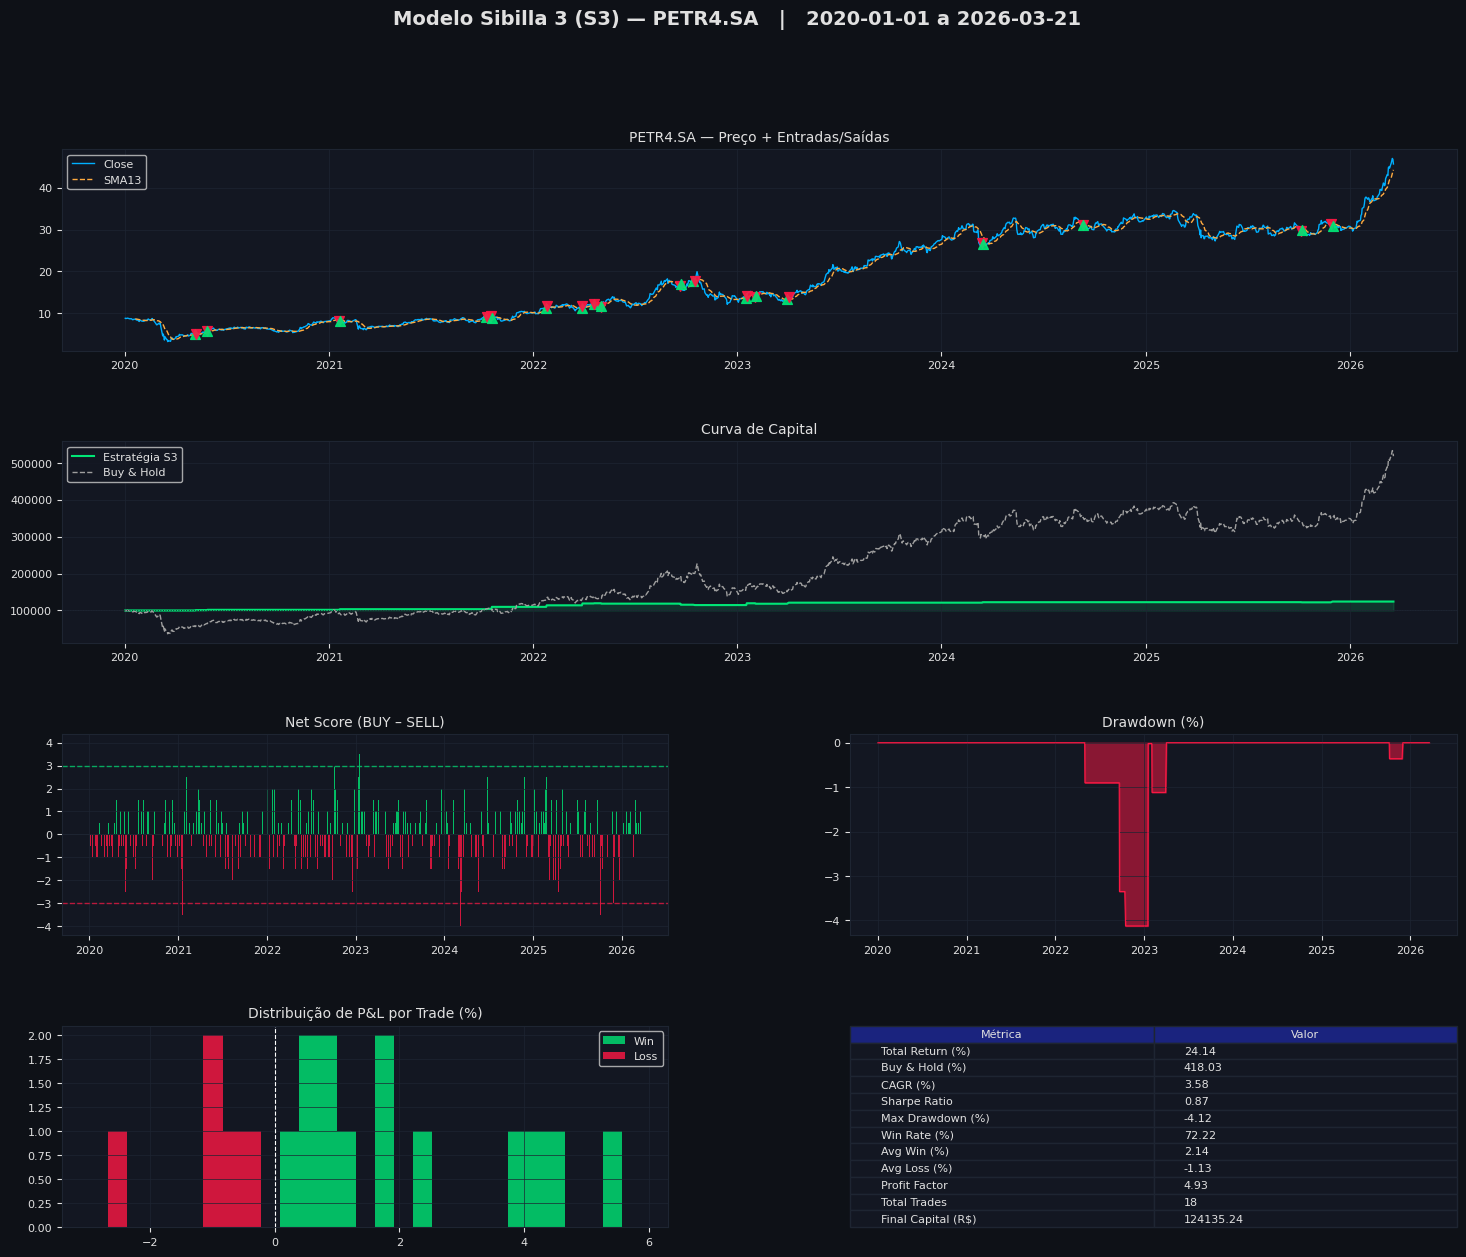

Gráfico salvo.


In [14]:
print(f"\n{'='*60}")
print(f"  Modelo Sibilla 3 (S3) — Backtest")
print(f"  Ativo : {TICKER}  |  {START_DATE} → {END_DATE}")
print(f"{'='*60}\n")

print("[ 1/4 ] Baixando dados...")
df = load_data(TICKER, START_DATE, END_DATE)
print(f"        {len(df)} pregões carregados.\n")

print("[ 2/4 ] Calculando scores S3...")
df = calculate_scores(df)
print(f"        Scores calculados. Net score médio: {df['net_score'].mean():.2f}\n")

print("[ 3/4 ] Rodando backtest...")
df, trades_df = run_backtest(df)
print(f"        {len(trades_df)} trades executados.\n")

print("[ 4/4 ] Computando métricas...")
metrics = compute_metrics(df, trades_df)

print("\n─── RESULTADOS ──────────────────────────────────────────")
for k, v in metrics.items():
    print(f"  {k:<25} {v}")
print("─────────────────────────────────────────────────────────\n")

if not trades_df.empty:
    print("─── ÚLTIMOS 10 TRADES ───────────────────────────────────")
    cols = ["direction", "entry_date", "exit_date",
            "entry_price", "exit_price", "pnl_pct", "exit_reason"]
    print(trades_df[cols].tail(10).to_string(index=False))
    print()

plot_results(df, trades_df, metrics, TICKER)
# return df, trades_df, metrics


"""
Backtest - Modelo Sibilla 3 (S3)
=================================
Estratégia seguidor de tendência de curto prazo (até 15 dias).

Indicadores (scoring):
  1. Breakout/Breakdown de 3 dias         → ±1.0 ponto
  2. Cruzamento de SMA 13 dias            → ±1.0 ponto
  3. Padrões de candles (3 formações)     → ±1.5 pontos
     3.1 Stars                             → ±0.5
     3.2 Engulfing                         → ±0.5
     3.3 Inverted Hammer / Shooting Star  → ±0.5
  4. Tamanho do corpo do candle           → ±1.0 ponto
  5. Acumulação & Distribuição            → ±1.5 pontos

Parâmetros de entrada:
  - Compra : Net Score (BUY – SELL) >= +3.0
  - Venda  : Net Score              <= -3.0

Parâmetros de saída:
  - Stop Loss de 2%
  - Retração do score líquido para <= +1 (posição comprada)
  - Retração do score líquido para >= -1 (posição vendida)
"""
